6.0. - Drawing Graphs

- Visualizar dados é uma das mais importantes tarefas na análise de dados por dois motivos:
  1. Gerar um relatório gráfico é uma forma muito mais simples, compreensível, limpa e bonita de explicar para outras pessoas o que aqueles dados dizem
  2. Gerar um gráfico também é útil para que o analista entenda o que os dados revelam, facilitando uma análise exploratória

- Para ilustrar a importância de gráficos para a análise dos dados, o autor comenta sobre um caso de cólera ocorrido em 1854, onde o médico John Snow, após mapear a área da cidade colocando pontos laranjas nos locais com casos de cólera e círculos azuis em bombas d'água, conseguiu identificar claramente após a análise gráfica o local que deu início ao surto da doença e evitar a morte de mais pessoas

---

6.1. - An overview of Python graphics

- Criar gráficos em Python é como pintar um quadro; Você começa com um quadro em branco e apartir de funções vai adicionando dados ao quadro, o problema é que, assim como pinturas na vida real, quando erros são cometidos você deve iniciar o processo do zero

- Biblioteca de plotagem: Um conjunto de comandos sobre como e onde desenhar no quadro -> `matplotlib`

- Matplotlib é uma biblioteca poderosa para criação de gráficos, mas difícil de se lidar em alguns momentos. Devido a essa dificuldade, bibliotecas mais simples como `seaborn` (geralmente usado para gráficos estatísticos estilizados) são usadas em conjunto

- Python não possui uma única maneira de produzir gráficos, na verdade, a linguagem é uma plataforma aberta de criação que dá liberdade a qualquer pessoa desenvolver sua própria ferramenta destinada ao mesmo objetivo

---

6.2. - An introduction to plotting

- Antes de iniciar os estudos, vamos ver um exemplo prático da criação de um gráfico com a sequência de Fibonacci


<Axes: >

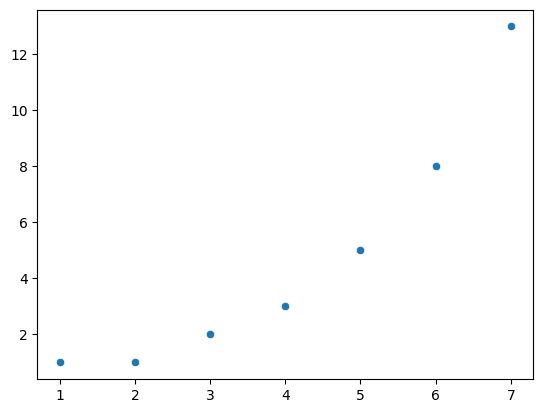

In [ ]:
import seaborn as sns

fibonacci = [1,1,2,3,5,8,13]
x = [1,2,3,4,5,6,7] # Armazena a quantidade de elementos de fibonacci

sns.scatterplot(x = x, y = fibonacci)

6.2.1. - A little color

- Nota-se que o Seaborn já possui por padrão alguns parâmetros para a construção do gráfico, como a cor azul para os pontos e o tamanho de cada um deles, mas esses parâmetros podem ser ajustados conforme a necessidade ou gosto do programador

<Axes: >

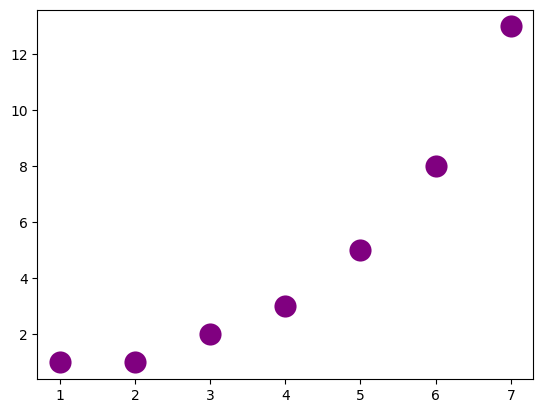

In [ ]:
sns.scatterplot(x=x, y=fibonacci, s=300, color="purple")

6.2.2. - Title and axis labels

- A maneira mais simples de acioniar títulos e rótulos aos eixos é adicionando o gráfico à uma variável e setar com o método `set` essas informações, por exemplo:

[Text(0.5, 1.0, 'Meu título'), Text(0.5, 0, 'Eixo X'), Text(0, 0.5, 'Eixo Y')]

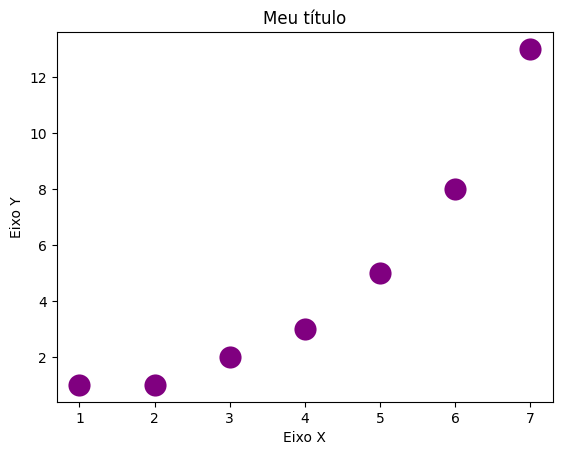

In [ ]:
graph = sns.scatterplot(x=x, y=fibonacci, s=300, color="purple")
graph.set(title="Meu título", xlabel="Eixo X", ylabel="Eixo Y")

6.2.3. - Font size and related matters

- Há diferentes maneiras de editar fontes, cores, rótulos, etc, o que o Seaborn proporciona é uma forma mais prática de fazer essas aleterações. A partir do método `set_context` é possível dizer ao Seaborn onde o gráfico será exibido, por exemplo, em um "paper", "poster", "talk" ou no caso atual em um "notebook", esses parâmetros basicamente dizem ao Seaborn o quão largo a fonte e outros elementos devem ser (com o tamanho padrão sendo 1)

[Text(0.5, 1.0, 'Meu título'), Text(0.5, 0, 'Eixo X'), Text(0, 0.5, 'Eixo Y')]

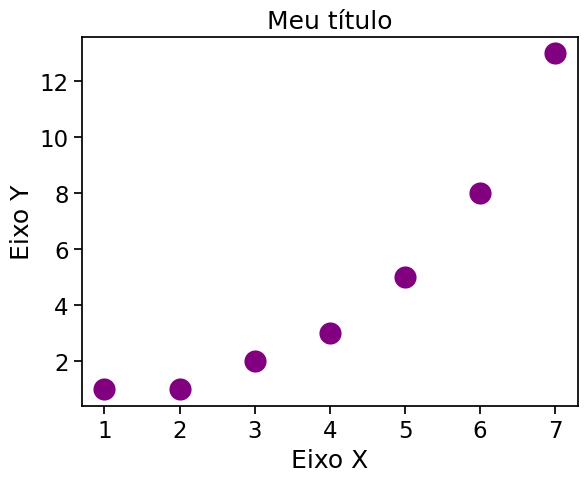

In [ ]:
sns.set_context("notebook", font_scale=1.5)
graph = sns.scatterplot(x = x, y = fibonacci, s = 300, color = "purple")
graph.set(title = "Meu título",
       xlabel = "Eixo X",
       ylabel="Eixo Y")

6.2.4. - Open the box

- Por padrão o Seaborn cria uma caixa na qual o gráfico é inserido e, em alguns casos, pode ser necessário remover algumas das bordas dessa caixa para melhor visualização ou aparência. Isso pode ser feito utilizando o método `despine`, passando True para os parâmetros das bordas que devem ser desativdas

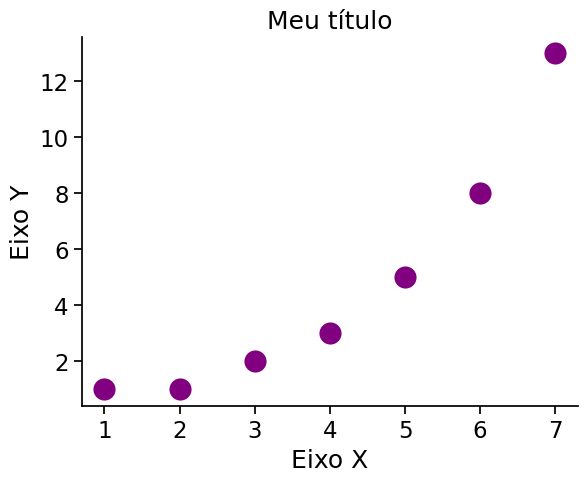

In [ ]:
sns.set_context("notebook", font_scale=1.5)
graph = sns.scatterplot(x = x, y = fibonacci, s = 300, color = "purple")
graph.set(title = "Meu título",
       xlabel = "Eixo X",
       ylabel="Eixo Y")

sns.despine(top=True, right=True)

6.3. - Plotting more complex data

- Para gerar gráficos mais complexos é necessário organizar os dados em um DataFrame Pandas

In [ ]:
import pandas as pd

afl_margins = pd.read_csv('https://raw.githubusercontent.com/ethanweed/pythonbook/main/Data/afl_margins.csv')

afl_margins.head()

,afl.margins
0,56
1,31
2,56
3,8
4,32


6.3.1. - Histograms

- Um histosgrama é um gráfico que mostra como os valores de uma variável contínua se distribuem, dividindo os dados em intervalos (bins) e exibindo quantas observações caem em cada intervalo. São úteis para comparar distribuições entre grupos. Pode ser obtido a partir da função `histplot` do Seaborn

<Axes: xlabel='afl.margins', ylabel='Count'>

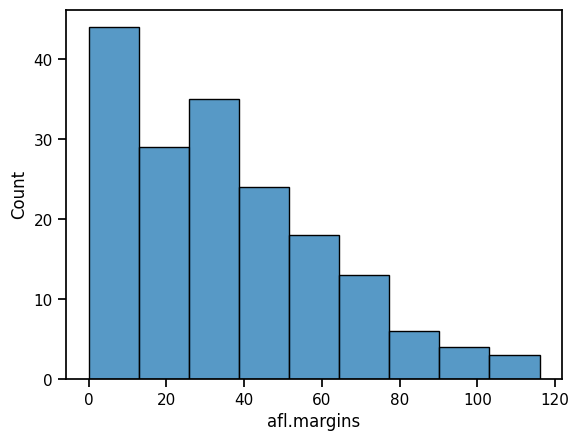

In [ ]:
# Célula para resetar as mudanças feitas anteriormente
sns.set_context("notebook", font_scale = 1)

sns.histplot(data = afl_margins, x="afl.margins")

- O ponto positivo de usar histogramas é nele é possível ter uma visão geral dos dados, o lado negativo é que eles não são compactos, o que pode ser prejudicial quando for necessário apresentar uma média/grande quantidade de histogramas de uma única vez

- Um das sutilezas que deve-se ter em mente quando um histograma é utilizado é na quantidade e valores de cada intervalo (bins), já que usar intervalos a menos ou a mais pode prejudicar no entendimento dos dados, por exemplo:

Text(0.5, 1.0, 'Intervalos de mais!')

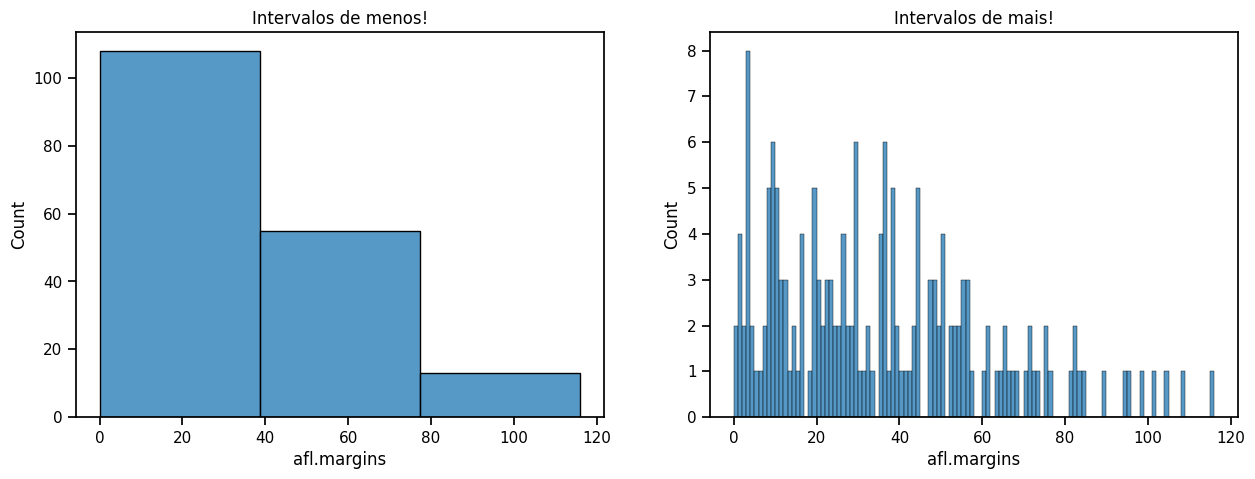

In [ ]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = sns.histplot(data = afl_margins, x="afl.margins", bins = 3, ax=axes[0])
ax2 = sns.histplot(data = afl_margins, x="afl.margins", bins = 116, ax=axes[1])

axes[0].set_title("Intervalos de menos!")
axes[1].set_title("Intervalos de mais!")

- O gráfico da direita possui 1 ponto de comprimento, o ponto positivo é que ele mostra em um único gráfico todo o conteúdo do DataFrame, o ponto negativo é que a sua leitura pode ser um pouco mais difícil

- Por outro lado, o gráfico da esquerda possui um comprimento de 50, tornando-o fácil de ler, mas não mostrando exatamente toda a informação dos dados

6.3.2. - Boxplots

- Um boxplot é um gráfico que resume a distribuição de uma variável mostrando seus quartis, mediana e possíveis outliers, destacando a tendência central, dispersão e assimetria. É utilizado quando é necessário comparar distribuições entre grupos de maneiras diretas ou quando se precisa identificar outliers e diferenças de variabilidade. Pode ser utilizado a partir da função `boxplot()` do Seaborn

- A fim de comparação será utilizado o método `describe()` do Pandas

In [ ]:
afl_margins.describe()

,afl.margins
count,176.000000
mean,35.301136
std,26.073636
min,0.000000
25%,12.750000
50%,30.500000
75%,50.500000
max,116.000000


<Axes: ylabel='afl.margins'>

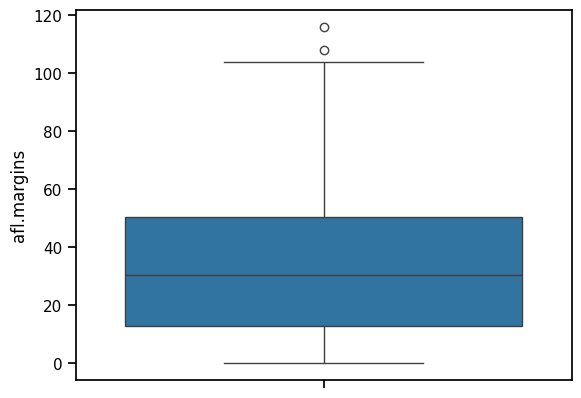

In [ ]:
sns.boxplot(data=afl_margins, y="afl.margins")

- O gráfico deve ser interpretado da seguinte maneira:
  1. A linha no centro da caixa azul é a mediana;
  2. A caixa cobre o intervalo do 25º percentil (25%) ao 75º percentil (75%) -> A caixa é onde se localiza a maior parte das observações, uma caixa larga significa muita dispersão, uma caixa estreita significa pouca variabilidade;
  3. Os bigodes (whiskers) vão ao limite inferior ao superior, de forma que: Q1 - 1.5 * IQR até Q3 + 1.5 * IQR. Os bigodes mostram até onde faz sentido considerar os dados normais;
  4. Os pontos fora dos bigodes são os outliers (valores muito acima ou muito abaixo do esperado pela distribuição geral).

- Como agora estamos lidando com um DataFrame, é importante ressaltar que ao criar um novo gráfico é importante passar a variável do DataFrame ao parâmetro `data = afl_margins` e a coluna que será utilizada no eixo x `x = "afl_margins"` ou y `y = "afl_margins"`

- É possível criar gráficos na horizontal apenas mudando a variáve que receberá a coluna:

<Axes: xlabel='afl.margins'>

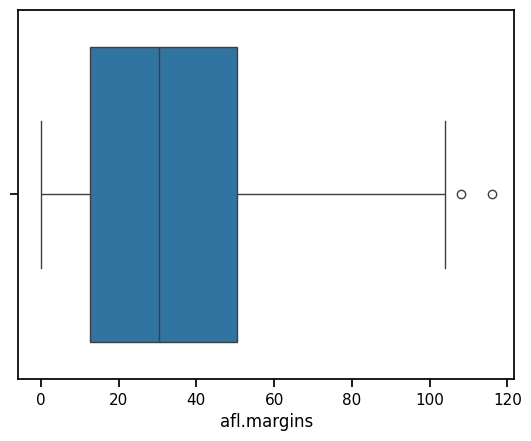

In [ ]:
sns.boxplot(data = afl_margins, x = 'afl.margins')

- Geralmente o boxplot é utilizado de maneira informal para detectar outliers (observações distantes do resto dos dados).

- Supondo um caso em que um dos dados foi acima de 300:

<Axes: xlabel='afl.margins'>

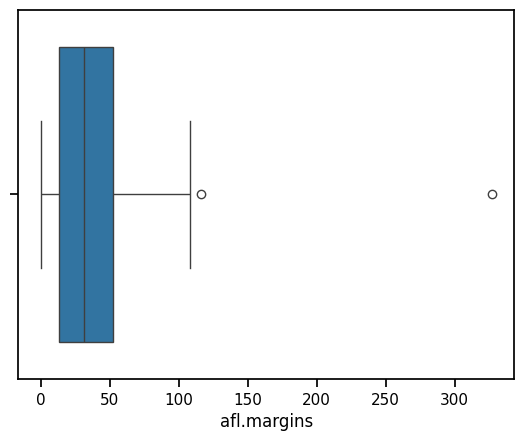

In [ ]:
afl_margins.loc[177] = 327
sns.boxplot(data = afl_margins, x = 'afl.margins')

- Para capturar o valor exato da anomalia basta fazer a filtragem pelo termo desejado

In [ ]:
afl_margins[afl_margins['afl.margins'] > 300]

,afl.margins
177,327


- Dessa forma é possível identificar exatamente o valor e a posição da anomalia. Analisando a anomalia com os demais erros, é possível presumir que houve um erro de digitação, sendo assim, é possível corrigir o erro utilizando `afl_margins.loc[177] = 33`

6.3.3. - Drawing multiple boxplots

- É possível também desenhar multiplos boxplots, para exemplificar será carregado um novo dataset com os dados da AFL de 1987 a 2010

- Dessa forma é possível exibir vários dados em um único gráfico, diferente do histograma, que seria necessário criar vários gráficos para exibir os dados em sua totalidade

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/ethanweed/pythonbook/main/Data/afl2small.csv')
print(df.head()) # Exibe as 5 primeiras linhas do DataFrame
print(df.tail()) # Exibe as 5 últimas linhas do DataFrame

   margin  year
0      33  1987
1      59  1987
2      45  1987
3      91  1987
4      39  1987
      margin  year
4291       5  2010
4292      41  2010
4293      24  2010
4294       0  2010
4295      56  2010


- Para plotar esses dados basta chamar a função `boxplot()` novamente, passando a coluna 'year' para o parâmetro x e 'margin' para o parâmetro y

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, '1987'),
  Text(1, 0, '1988'),
  Text(2, 0, '1989'),
  Text(3, 0, '1990'),
  Text(4, 0, '1991'),
  Text(5, 0, '1992'),
  Text(6, 0, '1993'),
  Text(7, 0, '1994'),
  Text(8, 0, '1995'),
  Text(9, 0, '1996'),
  Text(10, 0, '1997'),
  Text(11, 0, '1998'),
  Text(12, 0, '1999'),
  Text(13, 0, '2000'),
  Text(14, 0, '2001'),
  Text(15, 0, '2002'),
  Text(16, 0, '2003'),
  Text(17, 0, '2004'),
  Text(18, 0, '2005'),
  Text(19, 0, '2006'),
  Text(20, 0, '2007'),
  Text(21, 0, '2008'),
  Text(22, 0, '2009'),
  Text(23, 0, '2010')])

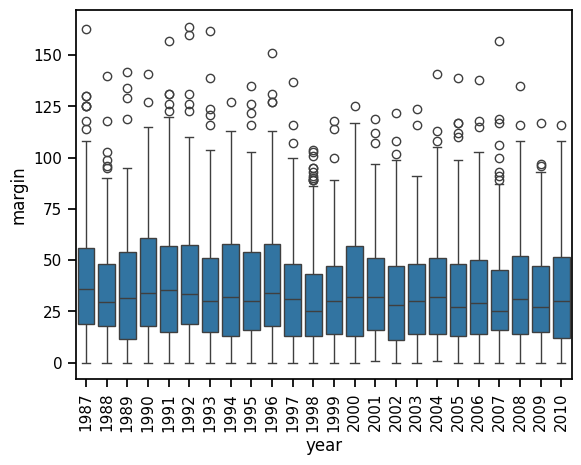

In [ ]:
graph = sns.boxplot(x = 'year', y = 'margin', data = df)
plt.xticks(rotation=90) # Ajusta as legendas para evitar sobreposição

6.3.4. - Alternatives to boxplots

- Há diferentes maneiras de resumir dados visualmente além do boxplot, no exemplo abaixo o primeiro gráfico é o padrão com `boxplot()`, o segundo foi feito utilizando o `stripplot()` (que plota os dados em pontos) e o terceiro é o `violinplot()` (que é utilizado para resolver o problema de não exibição da mediana e quartis)

6.3.4.1. - A word of caution on violin plots

- Enquanto o boxplot e stipplot exibem as exatas características dos dados, o violinplot apresenta uma estimativa que tenta mostrar a distribuição subjacente dos dados. Sendo assim, o gráfico do violinplot não pode ser interpretado exatamente da mesma forma que o boxplot, por exemplo.

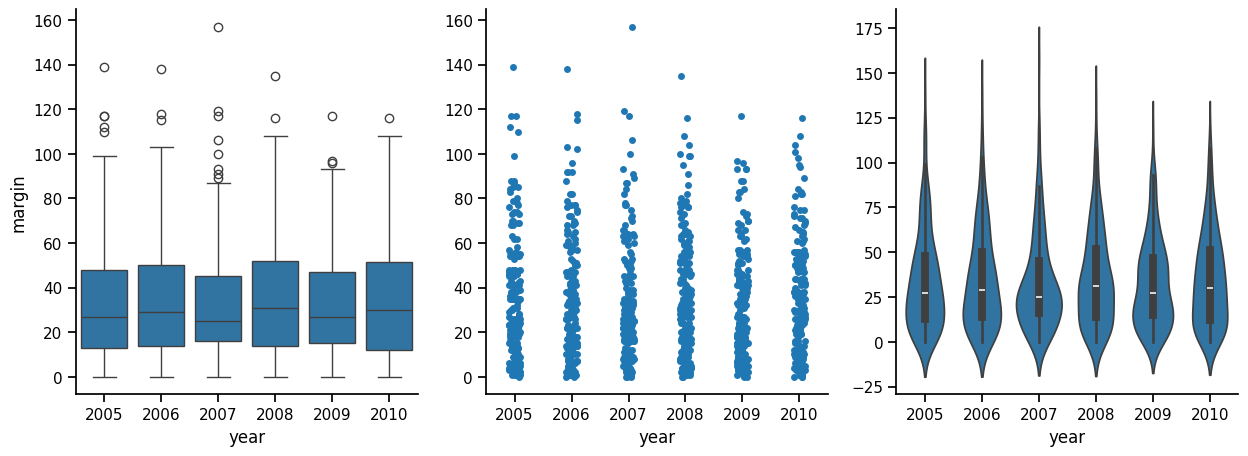

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/ethanweed/pythonbook/main/Data/afl2small.csv')
df = df[df['year'] > 2004]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax1 = sns.boxplot(x = 'year', y = 'margin', data = df, ax=axes[0])
ax2 = sns.stripplot(x = 'year', y = 'margin', data = df, ax=axes[1])
ax3 = sns.violinplot(x = 'year', y = 'margin', data = df, ax=axes[2])

ax2.set(ylabel = '')
ax3.set(ylabel = '')

for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

- Um outro recurso é a plotagem de dados por cima de um gráfico já existe, unindo o melhor de dois gráficos diferentes. Um possível problema que isso pode gerar é, obviamente, a sobreposição de algum dado importante

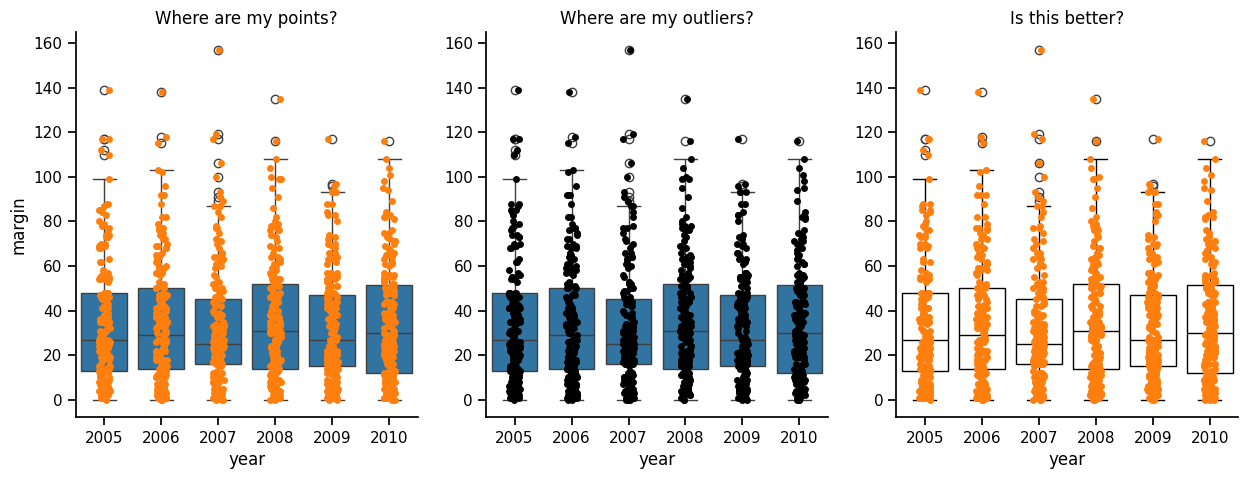

In [ ]:
properties = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


ax1 = sns.boxplot(x = 'year', y = 'margin', data = df, ax=axes[0])
ax1 = sns.stripplot(x = 'year', y = 'margin', data=df, ax=axes[0])

ax2 = sns.boxplot(x = 'year', y = 'margin', data = df, ax=axes[1])
ax2 = sns.stripplot(x = 'year', y = 'margin', data=df, color = 'black', ax=axes[1])

ax3 = sns.boxplot(x = 'year', y = 'margin', data = df, **properties, ax=axes[2])
ax3 = sns.stripplot(x = 'year', y = 'margin', data=df, ax=axes[2])

axes[0].set_title("Where are my points?")
axes[1].set_title("Where are my outliers?")
axes[2].set_title("Is this better?")


ax2.set(ylabel = '')
ax3.set(ylabel = '')

for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

6.4. - Scatterplots

- O scatterplot é um gráfico de dispersão em que cada ponto corresponde a uma observação, sendo a sua posição horizontal a representação do valor da observação e a posição vertical o valor em outra variável. Por convenção, a variável causal é plotada no eixo X e a variável de efeito no eixo Y

- O primeiro gráfico exibido nessas anotações era um scatterplot, que é um gráfico de dispersão de pontos, mas esse novo gráfico irá mostrar a relação entre duas variáveis ao invés de apenas uma

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/ethanweed/pythonbook/main/Data/parenthood.csv')
df.head()

,dan_sleep,baby_sleep,dan_grump,day
0,7.59,10.18,56,1
1,7.91,11.66,60,2
2,5.14,7.92,82,3
3,7.71,9.61,55,4
4,6.68,9.75,67,5


- Supondo que a análise a ser feita seja a relação das horas de sono da coluna `dan_sleep` em relação ao nível de ranzinza no dia seguinte da coluna `dan_grump`

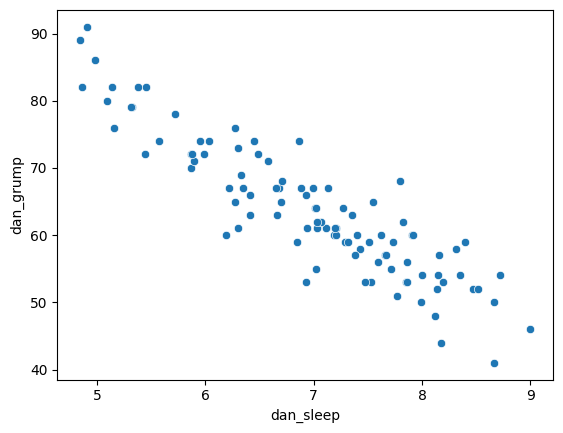

In [5]:
ax = sns.scatterplot(x = 'dan_sleep', y = 'dan_grump', data = df)

- É possível notar a relação entre as horas de sono e o nível de ranzinza, mas para ficar ainda mais evidente podemos adicionar uma linha que percorre a região central entre os pontos. Essa alteração pode ser feita ao substituir o `scatterplot` por um `regplot()`

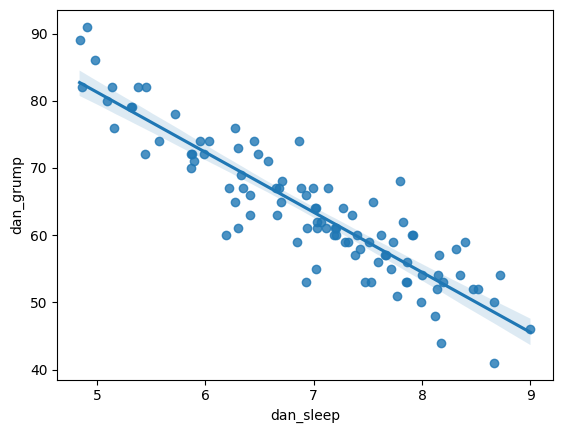

In [6]:
ax = sns.regplot(x = 'dan_sleep', y = 'dan_grump', data = df)

- Sem a linha seria possível fazer a interpretação gráfica, mas com ela temos um palpite melhor para analisar a relação entre as duas variáveis. A região translúcida ao redor da linha representa o intervalo de confiança do modelo, como ela está muito próxima da linha, significa que o gráfico fez um bom trabalho para representar o mais fiel possível a relação entre os dados

6.5. - Bar graphs

- O gráfico de barras é o mais clássico entre todos os apresentados até o momento. Para ilustrar seu funcionamento será utilizado um dataset dos finalistas da AFL

In [11]:
df = pd.read_csv('https://raw.githubusercontent.com/ethanweed/pythonbook/main/Data/afl_finalists.csv')
# count up the number of times each team has been in the finals
finalists = df['afl.finalists'].value_counts()

# convert the result to a dataframe
df2 = finalists.to_frame()

# convert the row names to a column of data
df2.index.name = 'Team'
df2.reset_index(inplace=True)

# rename columns with clearer names
df2.columns = ['Team', 'Finals']

df2

,Team,Finals
0,Geelong,39
1,West Coast,38
2,Essendon,32
3,Melbourne,28
4,Collingwood,28
5,North Melbourne,28
6,Hawthorn,27
7,Carlton,26
8,Sydney,26
9,Adelaide,26


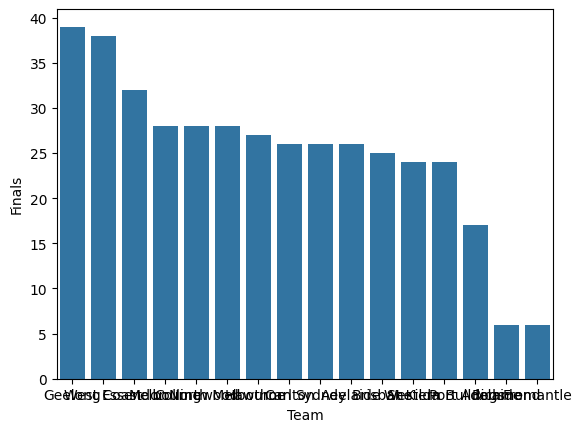

In [17]:
ax = sns.barplot(x = 'Team', y = 'Finals', data = df2)

- Nota-se que o nome dos times acabaram sobrepondo uns aos outros, uma maneira simples de solucionar esse problema seria plotar os dados no eixo y ao invés do eixo x

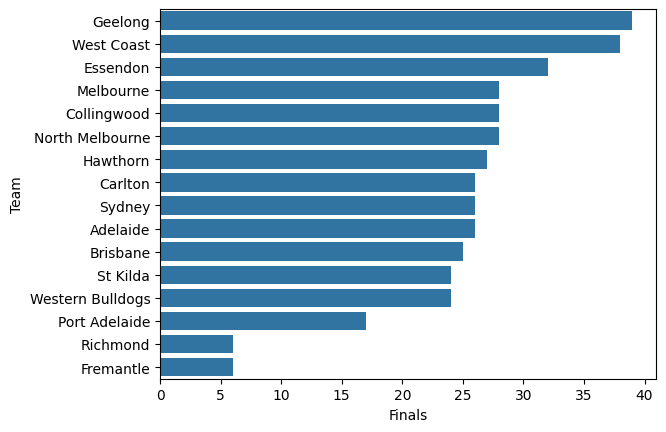

In [18]:
ax = sns.barplot(x = 'Finals', y = 'Team', data = df2)

- Ainda é possível melhorar a apresentação do gráfico adicionando labels para os eixos e um título ao gráfico

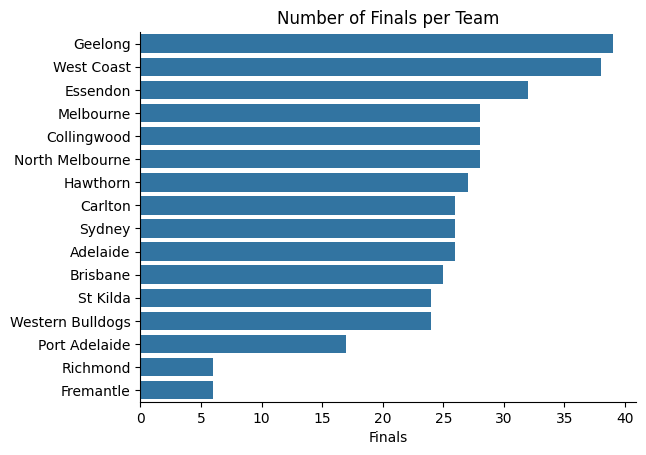

In [19]:
ax = sns.barplot(x = 'Finals', y = 'Team', data = df2)
ax.set(title = 'Number of Finals per Team', xlabel = 'Finals', ylabel='')
sns.despine(top=True, right=True)

6.6. - Saving image files

- Uma das formas mais simples de salvar os gŕaficos gerados é utilizando o comando `savefig` da biblioteca Matplotlib

- Alguns pontos importantes a se considerar são os valores passados para os argumentos `facecolor` e `bbox_inches`, que se não forem definidos, respectivamente, como "white" e "tight" irão salvar um gráfico diferente do que foi gerado

mkdir: cannot create directory ‘output’: File exists


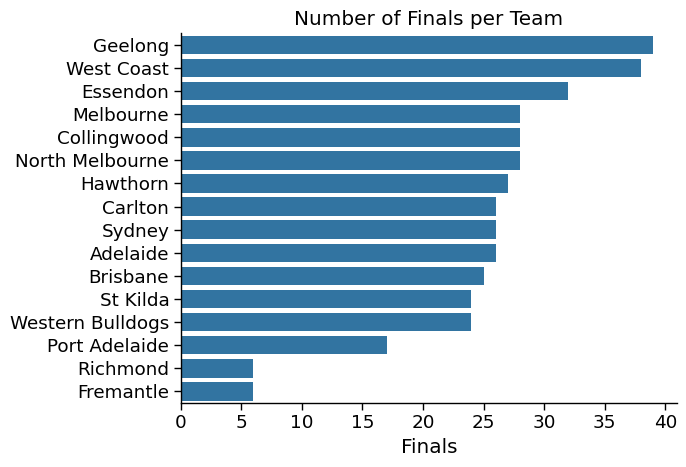

In [23]:
import seaborn as sns
from matplotlib import pyplot as plt

ax = sns.barplot(x = 'Finals', y = 'Team', data = df2)
ax.set(title = 'Number of Finals per Team', xlabel = 'Finals', ylabel='')
sns.despine(top=True, right=True)
sns.set_context("paper", font_scale=1.5)

!mkdir output # Cria uma pasta onde será salvo o arquivo
plt.savefig('/content/output/grafico.png', facecolor='white', bbox_inches='tight')

6.7. - Enough for now

- Essas são só algumas poucas configurações e tipos possíveis de gráficos, muito mais pode ser feito com o Seaborn ou com a junção do Seaborn + Matplotlib